# Naive Bayes - Survei Penggunaan Belajar Online
Notebook ini membuat model klasifikasi Naive Bayes untuk memprediksi tingkat kepuasan pengguna platform belajar online.

In [7]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [8]:
csv_path = 'Survei Penggunaan Platform Belajar Online pada Mahasiswa (Jawaban) - Form Responses 1.csv'
df = pd.read_csv(csv_path)

print('Ukuran data:', df.shape)
display(df.head())

Ukuran data: (25, 14)


,Timestamp,Nama lengkap,Asal universitas (cantumkan nama lengkap),Jurusan / program studi,Angkatan,Usia Anda?,Status/aktivitas utama Anda saat ini?,Platform Utama belajar online yang paling sering Anda gunakan?,Perangkat yang paling sering Anda gunakan untuk belajar online?,Rata-rata berapa jam per minggu Anda menggunakan platform belajar online?,Tujuan utama Anda menggunakan platform belajar online?,Jenis materi yang paling Anda sukai saat belajar online?,"Menurut Anda, berapa persentase materi/kursus/modul yang biasanya Anda selesaikan?",Seberapa puas Anda terhadap platform belajar online yang paling sering Anda gunakan?
0,08/04/2026 22:24:53,Fizar Erlansyah,Universitas Pembangunan Jaya,Sistem Informasi,2024,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,1–3 jam,Pengembangan karier,Campuran keduanya,81–100%,7
1,08/04/2026 22:27:50,Muhammad Rayhan Mumtaz,Universitas Pembangunan Jaya,Sistem Informasi,2024,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,4–6 jam,Keperluan akademik,Campuran keduanya,81–100%,8
2,08/04/2026 22:28:25,Panji Kurnia Akbar,Universitas Pembangunan Jaya,Sistem Informasi,2024,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,4–6 jam,Upgrade skill,Video,81–100%,8
3,08/04/2026 22:31:25,Azkiyah zhafirah,Universitas Pancasila,Farmasi,2025,18–24 tahun,Mahasiswa/pelajar,YouTube,HP / Mobile,7–10 jam,Keperluan akademik,Campuran keduanya,41–60%,7
4,08/04/2026 22:32:42,zavira verga,Universitas Pembangunan Jaya,accounting,2025,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,Lebih dari 20 jam,Keperluan akademik,Video,81–100%,9


In [9]:
target_col = 'Seberapa puas Anda terhadap platform belajar online yang paling sering Anda gunakan?'

# Ubah skor kepuasan (1-10) menjadi 3 kelas agar cocok untuk klasifikasi.
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col]).copy()
df['Label Kepuasan'] = pd.cut(
    df[target_col],
    bins=[0, 6, 8, 10],
    labels=['Rendah', 'Sedang', 'Tinggi'],
    include_lowest=True
)

drop_cols = [
    'Timestamp',
    'Nama lengkap',
    'Asal universitas (cantumkan nama lengkap)',
    target_col
]

feature_cols = [c for c in df.columns if c not in drop_cols + ['Label Kepuasan']]
X = df[feature_cols].astype(str)
y = df['Label Kepuasan'].astype(str)

print('Fitur yang digunakan:', feature_cols)
print('Distribusi kelas target:')
print(y.value_counts())

Fitur yang digunakan: ['Jurusan / program studi', 'Angkatan', 'Usia Anda?', 'Status/aktivitas utama Anda saat ini?', 'Platform Utama belajar online yang paling sering Anda gunakan?', 'Perangkat yang paling sering Anda gunakan untuk belajar online?', 'Rata-rata berapa jam per minggu Anda menggunakan platform belajar online?', 'Tujuan utama Anda menggunakan platform belajar online?', 'Jenis materi yang paling Anda sukai saat belajar online?', 'Menurut Anda, berapa persentase materi/kursus/modul yang biasanya Anda selesaikan?']
Distribusi kelas target:
Label Kepuasan
Sedang    13
Tinggi     7
Rendah     5
Name: count, dtype: int64


In [10]:
stratify_y = y if y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_y
)

categorical_preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols)
    ],
    remainder='drop'
)

model = Pipeline(steps=[
    ('prep', categorical_preprocess),
    ('nb', MultinomialNB())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [11]:
acc = accuracy_score(y_test, y_pred)
print(f'Akurasi: {acc:.2%}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

print('Confusion Matrix:')
cm_df = pd.DataFrame(confusion_matrix(y_test, y_pred), index=sorted(y.unique()), columns=sorted(y.unique()))
display(cm_df)

Akurasi: 60.00%

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.00      0.00      0.00         1
      Sedang       0.60      1.00      0.75         3
      Tinggi       0.00      0.00      0.00         1

    accuracy                           0.60         5
   macro avg       0.20      0.33      0.25         5
weighted avg       0.36      0.60      0.45         5

Confusion Matrix:


,Rendah,Sedang,Tinggi
Rendah,0,1,0
Sedang,0,3,0
Tinggi,0,1,0


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print('Cross-validation accuracy per fold:', cv_scores)
print(f'Rata-rata CV accuracy: {cv_scores.mean():.2%}')
print(f'Standard deviasi CV: {cv_scores.std():.2%}')

Cross-validation accuracy per fold: [0.6 0.6 0.6 0.4 0.4]
Rata-rata CV accuracy: 52.00%
Standard deviasi CV: 9.80%


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'nb__alpha': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)
best_model = grid_search.best_estimator_

print('Alpha terbaik:', grid_search.best_params_['nb__alpha'])
print(f'Skor CV terbaik: {grid_search.best_score_:.2%}')

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

print(f'Akurasi test dengan alpha terbaik: {acc_best:.2%}')
print('\nClassification Report (best model):')
print(classification_report(y_test, y_pred_best, zero_division=0))

Alpha terbaik: 0.01
Skor CV terbaik: 60.00%
Akurasi test dengan alpha terbaik: 80.00%

Classification Report (best model):
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00         1
      Sedang       0.75      1.00      0.86         3
      Tinggi       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.58      0.67      0.62         5
weighted avg       0.65      0.80      0.71         5



## Evaluasi Best Model dengan Confusion Matrix

Bagian ini menampilkan confusion matrix dari model dengan alpha terbaik hasil tuning.

Interpretasi singkat:
- Baris menunjukkan kelas aktual.
- Kolom menunjukkan kelas prediksi.
- Nilai diagonal menunjukkan prediksi yang benar (semakin besar semakin baik).

Confusion Matrix (best model):


,Rendah,Sedang,Tinggi
Rendah,1,0,0
Sedang,0,3,0
Tinggi,0,1,0


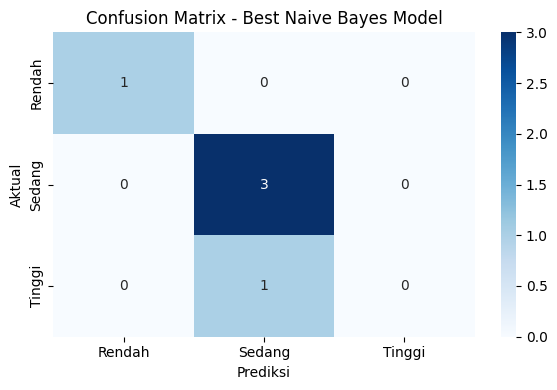

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(y.unique())
cm_best = confusion_matrix(y_test, y_pred_best, labels=labels)
cm_best_df = pd.DataFrame(cm_best, index=labels, columns=labels)

print('Confusion Matrix (best model):')
display(cm_best_df)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_best_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best Naive Bayes Model')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [12]:
def prediksi_kepuasan(data_baru: dict):
    """Prediksi kelas kepuasan dari 1 data responden baru."""
    input_df = pd.DataFrame([data_baru], columns=feature_cols).astype(str)
    return model.predict(input_df)[0]

contoh_data = {
    'Jurusan / program studi': 'Sistem Informasi',
    'Angkatan': '2024',
    'Usia Anda?': '18–24 tahun',
    'Status/aktivitas utama Anda saat ini?': 'Mahasiswa/pelajar',
    'Platform Utama belajar online yang paling sering Anda gunakan?': 'YouTube',
    'Perangkat yang paling sering Anda gunakan untuk belajar online?': 'Laptop',
    'Rata-rata berapa jam per minggu Anda menggunakan platform belajar online?': '4–6 jam',
    'Tujuan utama Anda menggunakan platform belajar online?': 'Keperluan akademik',
    'Jenis materi yang paling Anda sukai saat belajar online?': 'Video',
    'Menurut Anda, berapa persentase materi/kursus/modul yang biasanya Anda selesaikan?': '41–60%'
}

print('Prediksi kepuasan untuk data contoh:', prediksi_kepuasan(contoh_data))

Prediksi kepuasan untuk data contoh: Sedang
